# Phase 1

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve,classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import tensorflow as tf
from tensorflow.keras import layers, models

In [23]:
import pandas as pd
churn_data_df = pd.read_csv('/content/churn-bigml-80.csv')
churn_data_df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [24]:
churn_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [25]:
# dtypes
print(churn_data_df.dtypes)

State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


In [26]:
# Summary
churn_data_df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [27]:
churn_data_df.isna().sum().head()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0


# Phase 2

In [28]:
train_churn_df = pd.read_csv("/content/churn-bigml-80.csv")
test_churn_df = pd.read_csv("/content/churn-bigml-20.csv")

In [29]:
train_churn_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [30]:
print(f'nan in train = {train_churn_df.isna().sum().sum()}')
print(f'nan in test = {test_churn_df.isna().sum().sum()}')

nan in train = 0
nan in test = 0


In [31]:
X_train = train_churn_df.drop("Churn", axis=1)
y_train = train_churn_df["Churn"]
X_test = test_churn_df.drop("Churn", axis=1)
y_test = test_churn_df["Churn"]

In [32]:
num_features = X_train.select_dtypes(include='number').columns
cat_features = X_train.select_dtypes(include='object').columns

In [33]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# Phase 3

In [34]:
def build_model(variant="A", activation="relu"):
    if variant == "A":
        model = models.Sequential([
            layers.Dense(128, activation=activation),
            layers.Dense(1, activation="sigmoid")
        ])
    elif variant == "B":
        model = models.Sequential([
            layers.Dense(32, activation=activation),
            layers.Dense(32, activation=activation),
            layers.Dense(32, activation=activation),
            layers.Dense(32, activation=activation),
            layers.Dense(1, activation="sigmoid")
        ])
    elif variant == "C":
        model = models.Sequential([
            layers.Dense(64, activation="leaky_relu"),
            layers.Dense(1, activation="sigmoid")
        ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [35]:
modelA = build_model("A", "relu")
historyA = modelA.fit(preprocessor.fit_transform(X_train), y_train,
                      validation_split=0.2, epochs=50, batch_size=32)

modelA.summary()

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8250 - loss: 0.4453 - val_accuracy: 0.8258 - val_loss: 0.4053
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8644 - loss: 0.3351 - val_accuracy: 0.8333 - val_loss: 0.3753
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8804 - loss: 0.3026 - val_accuracy: 0.8502 - val_loss: 0.3433
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8949 - loss: 0.2719 - val_accuracy: 0.8764 - val_loss: 0.3130
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9062 - loss: 0.2484 - val_accuracy: 0.8801 - val_loss: 0.2955
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9142 - loss: 0.2299 - val_accuracy: 0.8895 - val_loss: 0.2858
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9198 - loss: 0.2165 - val_accuracy: 0.8820 - val_loss: 0.2781
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9240 - loss: 0.2069 - val_accuracy: 0.8895 - val_loss:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,037 (109.52 KB)

 Trainable params: 9,345 (36.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,692 (73.02 KB)

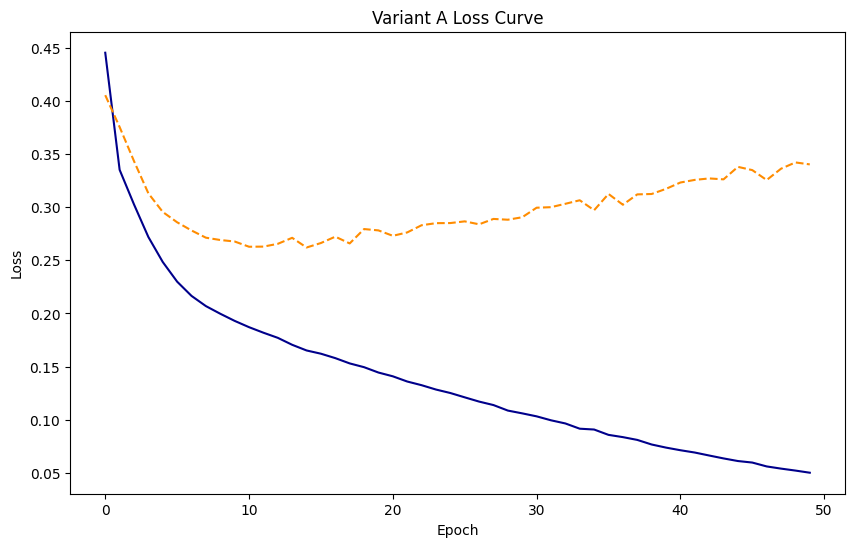

In [36]:
def plot_history(history, title, xlabel='Epoch', ylabel='Loss',
                 train_color='blue', val_color='orange',
                 train_linestyle='-', val_linestyle='--'):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='train', color=train_color, linestyle=train_linestyle)
    plt.plot(history.history['val_loss'], label='val', color=val_color, linestyle=val_linestyle)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

plot_history(historyA, "Variant A Loss Curve", train_color='darkblue', val_color='darkorange', train_linestyle='-', val_linestyle='--')

Model B Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,517 (64.52 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,012 (43.02 KB)

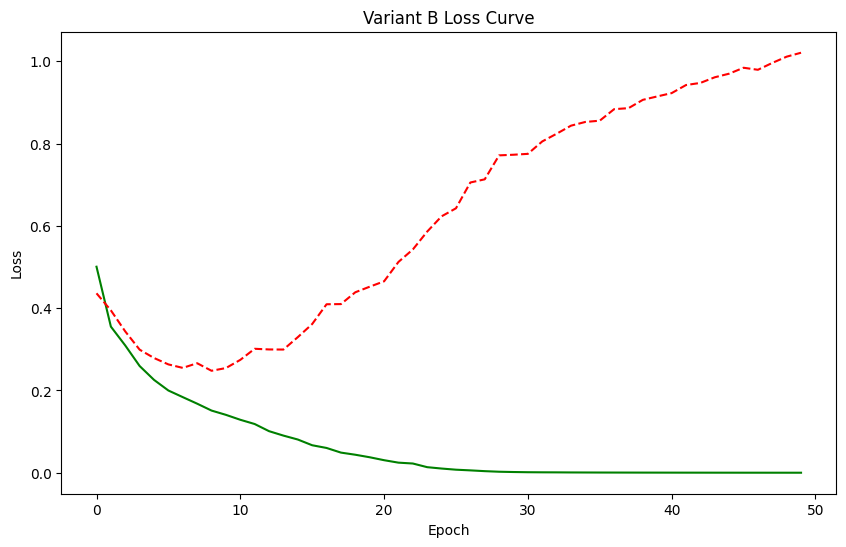

In [37]:
modelB = build_model("B", "relu")
historyB = modelB.fit(preprocessor.fit_transform(X_train), y_train,
                      validation_split=0.2, epochs=50, batch_size=32,
                      verbose=0)

print("Model B Summary:")
modelB.summary()
plot_history(historyB, "Variant B Loss Curve", train_color='green', val_color='red', train_linestyle='-', val_linestyle='--')

Model C Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,021 (54.77 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,348 (36.52 KB)

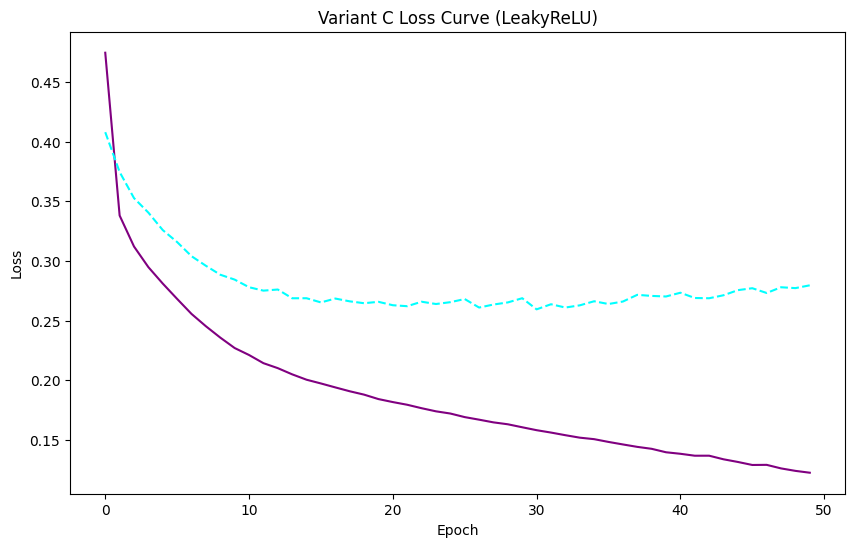

In [38]:
modelC = build_model("C", "leaky_relu")
historyC = modelC.fit(preprocessor.fit_transform(X_train), y_train,
                      validation_split=0.2, epochs=50, batch_size=32,
                      verbose=0)

print("Model C Summary:")
modelC.summary()
plot_history(historyC, "Variant C Loss Curve (LeakyReLU)", train_color='purple', val_color='cyan', train_linestyle='-', val_linestyle='--')

# Phase 4

In [39]:
def build_regularized_model(optimizer="adam", init="he_normal"):
    model = models.Sequential([
        layers.Dense(64, activation="relu", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [41]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
]

model_reg = build_regularized_model("adam", "he_normal")
history_reg = model_reg.fit(preprocessor.fit_transform(X_train), y_train,
                            validation_split=0.2, epochs=50, batch_size=32,
                            callbacks=callbacks)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5507 - loss: 0.8935 - val_accuracy: 0.7903 - val_loss: 0.5717 - learning_rate: 0.0010
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6398 - loss: 0.6756 - val_accuracy: 0.8240 - val_loss: 0.5001 - learning_rate: 0.0010
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7111 - loss: 0.5839 - val_accuracy: 0.8240 - val_loss: 0.4485 - learning_rate: 0.0010
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7758 - loss: 0.5062 - val_accuracy: 0.8315 - val_loss: 0.4106 - learning_rate: 0.0010
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8180 - loss: 0.4491 - val_accuracy: 0.8390 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8232 - loss: 0.4346 - val_accuracy: 0.8427 - val_loss: 0.3674 - learning_rate: 0.0010
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8438 - loss: 0.3914 - val_accuracy:

In [42]:
initializers = ["he_normal", "glorot_uniform"]
optimizers = {
    "adam": tf.keras.optimizers.Adam(),
    "sgd": tf.keras.optimizers.SGD(),
    "rmsprop": tf.keras.optimizers.RMSprop()
}

def build_test_model(init="he_normal", optimizer_obj=None):
    model = models.Sequential([
        layers.Dense(64, activation="relu", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer=optimizer_obj,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

In [43]:
results = {}

for init in initializers:
    for opt_name in optimizers.keys():
        print(f"\nTraining with init={init}, optimizer={opt_name}")
        if opt_name == "adam":
            current_optimizer = tf.keras.optimizers.Adam()
        elif opt_name == "sgd":
            current_optimizer = tf.keras.optimizers.SGD()
        elif opt_name == "rmsprop":
            current_optimizer = tf.keras.optimizers.RMSprop()

        model = build_test_model(init, optimizer_obj=current_optimizer)
        history = model.fit(preprocessor.fit_transform(X_train), y_train,
                            validation_split=0.2,
                            epochs=50,
                            batch_size=32,
                            verbose=0)

        val_acc = max(history.history['val_accuracy'])
        results[(init, opt_name)] = val_acc
        print(f"Best Val Accuracy: {val_acc:.4f}")


Training with init=he_normal, optimizer=adam
Best Val Accuracy: 0.9157

Training with init=he_normal, optimizer=sgd
Best Val Accuracy: 0.8596

Training with init=he_normal, optimizer=rmsprop
Best Val Accuracy: 0.9045

Training with init=glorot_uniform, optimizer=adam
Best Val Accuracy: 0.9176

Training with init=glorot_uniform, optimizer=sgd
Best Val Accuracy: 0.8801

Training with init=glorot_uniform, optimizer=rmsprop
Best Val Accuracy: 0.9157


In [44]:
df_results = pd.DataFrame([
    {"Initializer": init, "Optimizer": opt, "Best Val Acc": acc}
    for (init, opt), acc in results.items()
])

print(df_results)

      Initializer Optimizer  Best Val Acc
0       he_normal      adam      0.915730
1       he_normal       sgd      0.859551
2       he_normal   rmsprop      0.904494
3  glorot_uniform      adam      0.917603
4  glorot_uniform       sgd      0.880150
5  glorot_uniform   rmsprop      0.915730


# Phase 5

In [45]:
from imblearn.over_sampling import SMOTE

In [50]:
def justify_threshold(y_true, y_pred_proba, precision, recall, thresholds):
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores)

    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"Optimal Threshold (max F1-score): {optimal_threshold:.4f}")

    # Plot optimal threshold
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label='Precision-Recall Curve')
    plt.scatter(recall[optimal_idx], precision[optimal_idx], marker='o', color='red', label=f'Optimal Threshold ({optimal_threshold:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Optimal Threshold')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Evaluate with the optimal threshold
    y_pred_optimal = (y_pred_proba > optimal_threshold).astype(int)
    print(f"\nClassification Report at Optimal Threshold ({optimal_threshold:.4f}):")
    print(classification_report(y_true, y_pred_optimal))

Always No-Churn accuracy: 0.8575712143928036
Epoch 1/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.5131 - loss: 1.6535 - val_accuracy: 0.4925 - val_loss: 0.7164
Epoch 2/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5638 - loss: 1.3466 - val_accuracy: 0.6161 - val_loss: 0.6767
Epoch 3/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6088 - loss: 1.2714 - val_accuracy: 0.6929 - val_loss: 0.6199
Epoch 4/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6205 - loss: 1.1642 - val_accuracy: 0.7378 - val_loss: 0.5823
Epoch 5/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6402 - loss: 1.1387 - val_accuracy: 0.7509 - val_loss: 0.5607
Epoch 6/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6670 - loss: 1.0791 - val_accuracy: 0.7715 - val_loss: 0.5362
Epoch 7/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6979 - loss: 1.0075 - val_accuracy: 0.7828 - val_loss: 0.5186
Epoch 8/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.

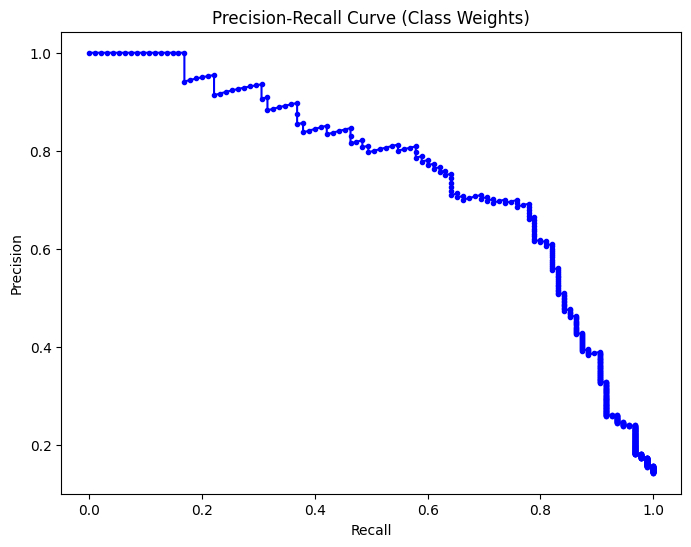

In [53]:
baseline_acc = (y_test == 0).mean()
print("Always No-Churn accuracy:", baseline_acc)

class_weight = {0:1, 1:sum(y_train==0)/sum(y_train==1)}

model_wt = build_regularized_model()
model_wt.fit(preprocessor.fit_transform(X_train), y_train,
             validation_split=0.2, epochs=25, batch_size=32,
             class_weight=class_weight)

y_pred_proba = model_wt.predict(preprocessor.transform(X_test))
prec, rec, thresh = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec, prec, color='blue', linestyle='-', marker='.', label='PR Curve') # Add color, linestyle, marker, label
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Class Weights)")
plt.show()

In [54]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Original training set shape: (2666, 71), (2666,)
SMOTE training set shape: (4556, 71), (4556,)
Class distribution after SMOTE: Churn
False    2278
True     2278
Name: count, dtype: int64
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Optimal Threshold (max F1-score): 0.4634


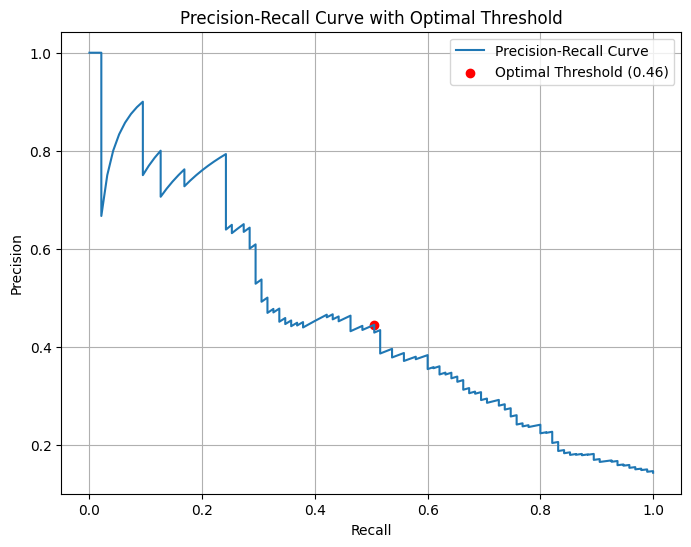


Classification Report at Optimal Threshold (0.4634):
              precision    recall  f1-score   support

       False       0.91      0.90      0.90       572
        True       0.44      0.49      0.47        95

    accuracy                           0.84       667
   macro avg       0.68      0.69      0.68       667
weighted avg       0.85      0.84      0.84       667



In [55]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Original training set shape: {X_train_processed.shape}, {y_train.shape}")
print(f"SMOTE training set shape: {X_train_smote.shape}, {y_train_smote.shape}")
print(f"Class distribution after SMOTE: {pd.Series(y_train_smote).value_counts()}")

model_smote = build_regularized_model()
history_smote = model_smote.fit(X_train_smote, y_train_smote,
                                validation_split=0.2, epochs=50, batch_size=32,
                                callbacks=callbacks,
                                verbose=0)

y_pred_proba_smote = model_smote.predict(X_test_processed)
precision_smote, recall_smote, thresholds_smote = precision_recall_curve(y_test, y_pred_proba_smote)
justify_threshold(y_test, y_pred_proba_smote, precision_smote, recall_smote, thresholds_smote)

# Phase 6

              precision    recall  f1-score   support

       False       0.97      0.88      0.92       572
        True       0.53      0.83      0.65        95

    accuracy                           0.87       667
   macro avg       0.75      0.85      0.78       667
weighted avg       0.91      0.87      0.88       667

ROC-AUC: 0.9143172616856828
Confusion Matrix:
 [[502  70]
 [ 16  79]]


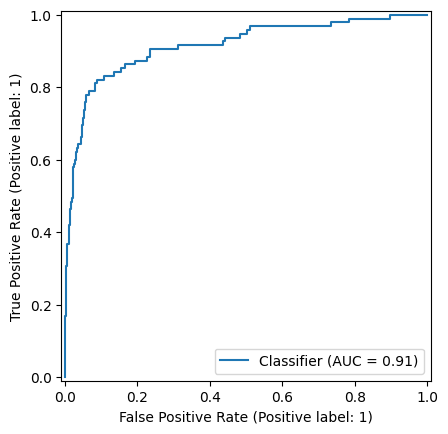

In [56]:
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.show()